# Ciudad Perdida (Teyuna) — Regional Location Map

Shaded-relief map of the Sierra Nevada de Santa Marta built from open SRTM 1-arc-second elevation
tiles (AWS Terrain Tiles, public, no API key). Hypsometric tint + hillshade, with the archaeological
site, main rivers, towns and the bounding fault systems annotated.

Output: `ciudad_perdida_location_map.svg`


In [2]:
import gzip
import math
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap, Normalize
from matplotlib.ticker import FormatStrFormatter

%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update({"font.family": "DejaVu Sans", "svg.fonttype": "none"})


In [3]:
# SRTM 1-arc-second DEM mosaic for the Sierra Nevada de Santa Marta

DEM_CACHE = Path("dem")
TILE_URL = "https://s3.amazonaws.com/elevation-tiles-prod/skadi/{ns}/{name}.hgt.gz"
SAMPLES = 3601  # 1 arc-second tile side

# lon_min, lon_max, lat_min, lat_max
EXTENT = (-74.55, -72.75, 10.35, 11.65)


def tile_name(lat, lon):
    return f"{'N' if lat >= 0 else 'S'}{abs(lat):02d}{'W' if lon < 0 else 'E'}{abs(lon):03d}"


def load_tile(lat, lon):
    """Return a 3601x3601 elevation array for the 1x1 deg tile with SW corner (lat, lon)."""
    DEM_CACHE.mkdir(exist_ok=True)
    name = tile_name(lat, lon)
    path = DEM_CACHE / f"{name}.hgt.gz"
    if not path.exists():
        url = TILE_URL.format(ns=name[:3], name=name)
        print(f"downloading {name} ...")
        urllib.request.urlretrieve(url, path)
    with gzip.open(path, "rb") as fh:
        data = np.frombuffer(fh.read(), dtype=">i2")
    return data.reshape(SAMPLES, SAMPLES).astype(np.float32)


def build_mosaic(extent):
    lon_min, lon_max, lat_min, lat_max = extent
    lons = range(math.floor(lon_min), math.floor(lon_max) + 1)
    lats = range(math.floor(lat_min), math.floor(lat_max) + 1)
    lat_top, lon_left = max(lats) + 1, min(lons)

    n = SAMPLES - 1
    mosaic = np.full((len(lats) * n + 1, len(lons) * n + 1), np.nan, dtype=np.float32)
    for la in lats:
        for lo in lons:
            r = (lat_top - (la + 1)) * n
            c = (lo - lon_left) * n
            mosaic[r:r + SAMPLES, c:c + SAMPLES] = load_tile(la, lo)

    # Crop to the requested extent
    row0 = int(round((lat_top - lat_max) * n))
    row1 = int(round((lat_top - lat_min) * n))
    col0 = int(round((lon_min - lon_left) * n))
    col1 = int(round((lon_max - lon_left) * n))
    return mosaic[row0:row1, col0:col1]


dem = np.clip(build_mosaic(EXTENT), 0.0, None)  # clamp SRTM voids / bathymetry to sea level
sea = dem <= 0
print(f"DEM {dem.shape}, elevation 0 - {dem.max():.0f} m, sea pixels {sea.mean():.1%}")


downloading N10W075 ...
downloading N10W074 ...
downloading N10W073 ...
downloading N11W075 ...
downloading N11W074 ...
downloading N11W073 ...
DEM (4680, 6480), elevation 0 - 5696 m, sea pixels 28.8%


Saved -> ciudad_perdida_location_map.svg


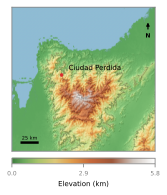

In [4]:
# Shaded-relief location map -> SVG

TEYUNA = (11.0378, -73.9252)

PLACES = [
    {"name": "Ciudad Perdida", "coords": TEYUNA, "kind": "site"},
    #{"name": "Santa Marta", "coords": (11.2408, -74.1990), "kind": "town"},
]

GRAY = "#808080"

# Hypsometric tint: lowland green -> tan -> orange -> brown -> snow
terrain = LinearSegmentedColormap.from_list("sierra", [
    (0.00, "#3f7d3f"), (0.08, "#6ba85c"), (0.18, "#a8c46a"), (0.30, "#ddc878"),
    (0.42, "#e09a4a"), (0.55, "#c6683a"), (0.70, "#9d5638"), (0.85, "#cfc6bf"),
    (1.00, "#ffffff"),
])
terrain.set_bad("#8fbcd4")

lon_min, lon_max, lat_min, lat_max = EXTENT
ls = LightSource(azdeg=315, altdeg=45)
land = np.ma.masked_where(sea, dem)

# Vertical exaggeration scaled to the ~30 m cell size
relief = ls.shade(land, cmap=terrain, norm=Normalize(0, 5750),
                  blend_mode="soft", vert_exag=2.5, dx=30, dy=30)

fig, ax = plt.subplots(figsize=(2.3, 3.5))
ax.set_facecolor("#8fbcd4")
ax.imshow(relief, extent=EXTENT, origin="upper", interpolation="bilinear", aspect="auto")

# Contour of the mountain front for context
contours = ax.contour(np.flipud(dem), levels=[1000, 3000, 5000], colors="black",
                      linewidths=0.35, alpha=0.35,
                      extent=EXTENT, origin="lower")
contours.set_rasterized(True)

styles = {
    "site": dict(marker=".", ms=6, mfc="#d92b2b", mec="#d92b2b", mew=0.6),
    #"town": dict(marker="o", ms=4, mfc="white", mec="black", mew=0.6),
}
for p in PLACES:
    lat, lon = p["coords"]
    ax.plot(lon, lat, ls="none", zorder=6, **styles[p["kind"]])
    ax.annotate(p["name"], xy=(lon, lat), xytext=(7, 5), textcoords="offset points",
                family="sans-serif", fontsize=7, zorder=7)

ax.set_box_aspect(1)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color(GRAY)

# Scale bar (km) and north arrow
km_per_deg_lon = 111.32 * math.cos(math.radians(11.0))
bar_km = 25
bx = lon_min + 0.06 * (lon_max - lon_min)
by = lat_min + 0.06 * (lat_max - lat_min)
ax.plot([bx, bx + bar_km / km_per_deg_lon], [by, by], color="black", lw=2.5,
        solid_capstyle="butt", zorder=8)
ax.text(bx + bar_km / km_per_deg_lon / 2, by + 0.012 * (lat_max - lat_min), f"{bar_km} km",
        ha="center", va="bottom", family="sans-serif", fontsize=5, zorder=8)
ax.annotate("N", xy=(lon_max - 0.09, lat_max - 0.12), xytext=(lon_max - 0.09, lat_max - 0.26),
            ha="center", va="center", family="sans-serif", fontsize=6, fontweight="bold",
            zorder=8, arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))

fig.tight_layout()

# Colorbar horizontal bajo el mapa, del mismo ancho que los ejes
fig.canvas.draw()
fig.set_layout_engine("none")  # tight_layout would otherwise re-run on every draw
pos = ax.get_position(original=False)  # aspect-adjusted box, not the requested one
cax = fig.add_axes([pos.x0, pos.y0 - 0.05, pos.width, 0.022])

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, 5.75), cmap=terrain), cax=cax,
                    orientation="horizontal")
cbar.set_ticks([0, 2.875, 5.75])
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
cbar.set_label("Elevation (km)", color="black", family="sans-serif", fontsize=7)
cbar.ax.tick_params(colors=GRAY, labelcolor=GRAY, labelsize=6)
for label in cbar.ax.get_xticklabels():
    label.set_family("sans-serif")
cbar.outline.set_edgecolor(GRAY)

fig.savefig("ciudad_perdida_location_map.svg", format="svg", bbox_inches="tight", dpi=200)
print("Saved -> ciudad_perdida_location_map.svg")